# Detección de tráfico anómalo en dispositivos IoT mediante aprendizaje automático

Este notebook evalúa modelos de aprendizaje automático sobre el dataset N-BaIoT para detectar tráfico benigno y tráfico asociado a botnets en dispositivos IoT.

Modelos evaluados:

- K-Means multiclase
- K-Means binario
- Gaussian Naive Bayes
- Isolation Forest multiclase adaptado

También se generan matrices de confusión, métricas de rendimiento, curvas ROC/AUC y pruebas de auditoría con registros individuales.

In [3]:
!pip install gdown

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import linear_sum_assignment

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    roc_curve,
    roc_auc_score
)

# Carpeta para guardar imágenes
os.makedirs("img", exist_ok=True)

In [5]:
file_id = "1iLGG2XlXTMJOA31HC8C5W4NKyPyAt3BK"
url = f"https://drive.google.com/uc?id={file_id}"
output = "dataset_iot_5_variables.csv"

!gdown {url} -O {output}

df = pd.read_csv(output)

# Limpiar nombres de columnas
df.columns = df.columns.str.strip()

df.head()

Downloading...
From: https://drive.google.com/uc?id=1iLGG2XlXTMJOA31HC8C5W4NKyPyAt3BK
To: /content/dataset_iot_5_variables.csv
100% 5.41M/5.41M [00:00<00:00, 52.8MB/s]


,Etiqueta,H_L0.1_weight,H_L0.1_mean,H_L0.1_variance,HH_jit_L0.01_mean,HpHp_L0.1_radius
0,benign,1.000000,60.000000,0.000000,1.505657e+09,0.00000
1,benign,1.626503,494.560774,14560.282180,3.620288e+01,14560.28218
2,benign,2.624581,530.924382,11160.824630,3.124701e+01,11160.82463
3,benign,1.000000,60.000000,0.000000,1.505657e+09,0.00000
4,benign,1.999588,66.001237,35.999998,7.528131e+08,0.00000


In [6]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nColumnas:")
print(df.columns)

print("\nDistribución de etiquetas:")
print(df["Etiqueta"].value_counts())

print("\nValores faltantes:")
print(df.isnull().sum())

Dimensiones del dataset:
(80000, 6)

Columnas:
Index(['Etiqueta', 'H_L0.1_weight', 'H_L0.1_mean', 'H_L0.1_variance',
       'HH_jit_L0.01_mean', 'HpHp_L0.1_radius'],
      dtype='object')

Distribución de etiquetas:
Etiqueta
benign         40000
gafgyt.scan    10000
mirai.scan     10000
gafgyt.udp     10000
mirai.udp      10000
Name: count, dtype: int64

Valores faltantes:
Etiqueta             0
H_L0.1_weight        0
H_L0.1_mean          0
H_L0.1_variance      0
HH_jit_L0.01_mean    0
HpHp_L0.1_radius     0
dtype: int64


In [7]:
columnas = [
    "H_L0.1_weight",
    "H_L0.1_mean",
    "H_L0.1_variance",
    "HH_jit_L0.01_mean",
    "HpHp_L0.1_radius"
]

etiquetas = sorted(df["Etiqueta"].unique())

X = df[columnas]
y_real = df["Etiqueta"]

print("Variables utilizadas:")
for col in columnas:
    print("-", col)

print("\nEtiquetas:")
print(etiquetas)

Variables utilizadas:
- H_L0.1_weight
- H_L0.1_mean
- H_L0.1_variance
- HH_jit_L0.01_mean
- HpHp_L0.1_radius

Etiquetas:
['benign', 'gafgyt.scan', 'gafgyt.udp', 'mirai.scan', 'mirai.udp']


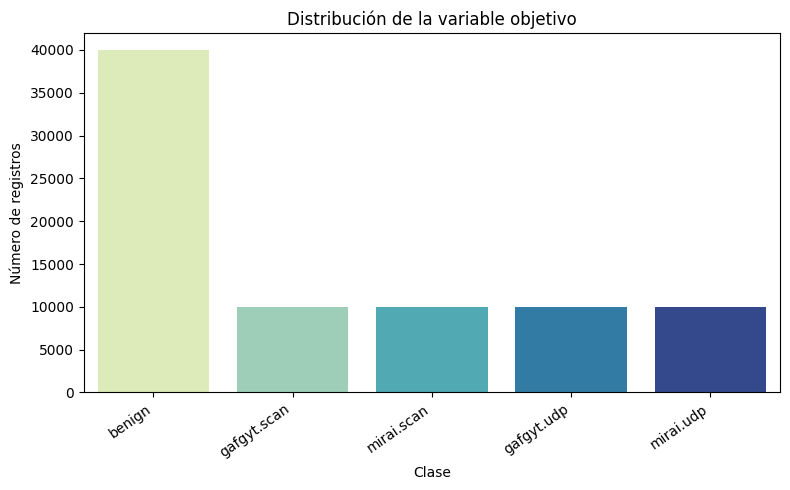

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Etiqueta",
    order=df["Etiqueta"].value_counts().index,
    hue="Etiqueta",
    palette="YlGnBu",
    legend=False
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Clase")
plt.ylabel("Número de registros")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig("img/distribucion_variable_objetivo.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
def mapear_clusters_a_etiquetas(y_real, clusters):
    """
    Mapea clusters numéricos a etiquetas reales usando asignación óptima.
    K-Means no asigna nombres de clase, por eso se hace este paso.
    """
    tabla = pd.crosstab(y_real, clusters)

    cost_matrix = -tabla.values
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    mapeo = {}

    for fila, columna in zip(row_ind, col_ind):
        etiqueta = tabla.index[fila]
        cluster = tabla.columns[columna]
        mapeo[cluster] = etiqueta

    return tabla, mapeo

In [10]:
def calcular_metricas(y_real, y_pred):
    """
    Calcula métricas principales usando promedio ponderado.
    """
    return {
        "Exactitud": accuracy_score(y_real, y_pred),
        "Precisión": precision_score(y_real, y_pred, average="weighted", zero_division=0),
        "Sensibilidad": recall_score(y_real, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_real, y_pred, average="weighted", zero_division=0)
    }

In [11]:
def graficar_matriz_confusion(matriz_df, titulo, archivo_salida, figsize=(10, 7)):
    """
    Genera una matriz de confusión con paleta YlGnBu.
    """
    plt.figure(figsize=figsize)

    sns.heatmap(
        matriz_df,
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        linewidths=0.5,
        linecolor="white",
        cbar=True
    )

    plt.title(titulo, fontsize=14, pad=15)
    plt.xlabel("Etiqueta predicha", fontsize=12, labelpad=10)
    plt.ylabel("Etiqueta real", fontsize=12, labelpad=10)

    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.savefig(archivo_salida, dpi=300, bbox_inches="tight")
    plt.show()

In [12]:
# Normalización para K-Means multiclase
scaler_kmeans_multi = MinMaxScaler()
X_scaled = scaler_kmeans_multi.fit_transform(X)

kmeans_multi = KMeans(
    n_clusters=5,
    init="random",
    max_iter=100,
    n_init=10,
    random_state=42
)

clusters_multi = kmeans_multi.fit_predict(X_scaled)

df_kmeans_multi = df.copy()
df_kmeans_multi["Cluster"] = clusters_multi

df_kmeans_multi.head()

,Etiqueta,H_L0.1_weight,H_L0.1_mean,H_L0.1_variance,HH_jit_L0.01_mean,HpHp_L0.1_radius,Cluster
0,benign,1.000000,60.000000,0.000000,1.505657e+09,0.00000,0
1,benign,1.626503,494.560774,14560.282180,3.620288e+01,14560.28218,2
2,benign,2.624581,530.924382,11160.824630,3.124701e+01,11160.82463,2
3,benign,1.000000,60.000000,0.000000,1.505657e+09,0.00000,0
4,benign,1.999588,66.001237,35.999998,7.528131e+08,0.00000,1


In [13]:
tabla_multi, mapeo_multi = mapear_clusters_a_etiquetas(
    df_kmeans_multi["Etiqueta"],
    df_kmeans_multi["Cluster"]
)

print("Tabla Etiqueta vs Cluster:")
display(tabla_multi)

print("\nMapeo cluster → etiqueta:")
print(mapeo_multi)

Tabla Etiqueta vs Cluster:


Cluster,0,1,2,3,4
Etiqueta,,,,,
benign,68,30889,9043,0,0
gafgyt.scan,6492,3508,0,0,0
gafgyt.udp,9990,10,0,0,0
mirai.scan,9930,70,0,0,0
mirai.udp,5,0,10,5739,4246



Mapeo cluster → etiqueta:
{np.int32(1): 'benign', np.int32(2): 'gafgyt.scan', np.int32(0): 'gafgyt.udp', np.int32(4): 'mirai.scan', np.int32(3): 'mirai.udp'}


In [14]:
df_kmeans_multi["Etiqueta_predicha"] = df_kmeans_multi["Cluster"].map(mapeo_multi)

matriz_confusion_multi = confusion_matrix(
    df_kmeans_multi["Etiqueta"],
    df_kmeans_multi["Etiqueta_predicha"],
    labels=etiquetas
)

matriz_confusion_multi_df = pd.DataFrame(
    matriz_confusion_multi,
    index=etiquetas,
    columns=etiquetas
)

matriz_confusion_multi_df

,benign,gafgyt.scan,gafgyt.udp,mirai.scan,mirai.udp
benign,30889,9043,68,0,0
gafgyt.scan,3508,0,6492,0,0
gafgyt.udp,10,0,9990,0,0
mirai.scan,70,0,9930,0,0
mirai.udp,0,10,5,4246,5739


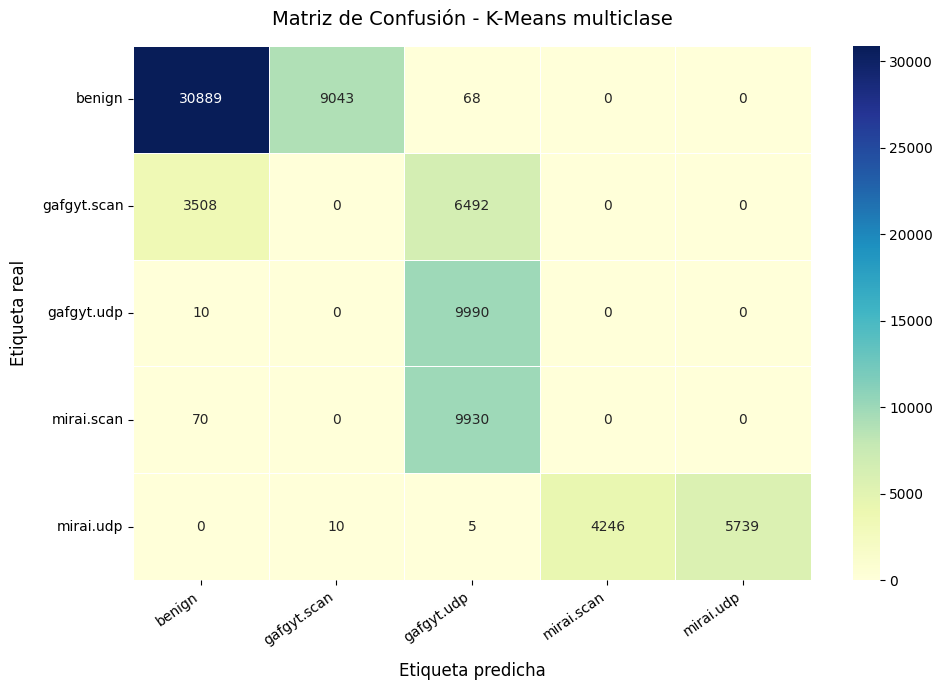

In [15]:
graficar_matriz_confusion(
    matriz_confusion_multi_df,
    "Matriz de Confusión - K-Means multiclase",
    "img/matriz_confusion_kmeans_5_variables_legible.png",
    figsize=(10, 7)
)

In [16]:
metricas_kmeans_multi = calcular_metricas(
    df_kmeans_multi["Etiqueta"],
    df_kmeans_multi["Etiqueta_predicha"]
)

ari_multi = adjusted_rand_score(
    df_kmeans_multi["Etiqueta"],
    df_kmeans_multi["Cluster"]
)

nmi_multi = normalized_mutual_info_score(
    df_kmeans_multi["Etiqueta"],
    df_kmeans_multi["Cluster"]
)

silhouette_multi = silhouette_score(
    X_scaled,
    df_kmeans_multi["Cluster"]
)

print("Métricas K-Means multiclase:")
for metrica, valor in metricas_kmeans_multi.items():
    print(f"{metrica}: {valor}")

print("Adjusted Rand Index:", ari_multi)
print("Normalized Mutual Information:", nmi_multi)
print("Silhouette Score:", silhouette_multi)

print("\nReporte de clasificación:")
print(classification_report(
    df_kmeans_multi["Etiqueta"],
    df_kmeans_multi["Etiqueta_predicha"],
    zero_division=0
))

Métricas K-Means multiclase:
Exactitud: 0.582725
Precisión: 0.6201146400161305
Sensibilidad: 0.582725
F1-score: 0.5743571853459557
Adjusted Rand Index: 0.5129478886803965
Normalized Mutual Information: 0.6451375947601969
Silhouette Score: 0.731673818164757

Reporte de clasificación:
              precision    recall  f1-score   support

      benign       0.90      0.77      0.83     40000
 gafgyt.scan       0.00      0.00      0.00     10000
  gafgyt.udp       0.38      1.00      0.55     10000
  mirai.scan       0.00      0.00      0.00     10000
   mirai.udp       1.00      0.57      0.73     10000

    accuracy                           0.58     80000
   macro avg       0.45      0.47      0.42     80000
weighted avg       0.62      0.58      0.57     80000



In [17]:
centroides_multi = pd.DataFrame(
    scaler_kmeans_multi.inverse_transform(kmeans_multi.cluster_centers_),
    columns=columnas
)

centroides_multi["Cluster"] = centroides_multi.index
centroides_multi["Etiqueta_asignada"] = centroides_multi["Cluster"].map(mapeo_multi)

centroides_multi

,H_L0.1_weight,H_L0.1_mean,H_L0.1_variance,HH_jit_L0.01_mean,HpHp_L0.1_radius,Cluster,Etiqueta_asignada
0,987.855039,64.265811,491.154231,1.420009e+09,4.782522e-10,0,gafgyt.udp
1,114.925159,76.678061,892.326107,4.806645e+07,5.667637e+03,1,benign
2,56.879653,154.276893,44074.262156,6.152591e+06,5.570529e+04,2,gafgyt.scan
3,2996.337511,349.770137,59123.441117,1.878782e+06,-9.739483e-10,3,mirai.udp
4,3012.538332,349.460279,59149.543033,1.507656e+09,-8.373048e-10,4,mirai.scan


In [18]:
df_binario = df.copy()

df_binario["Etiqueta_binaria"] = df_binario["Etiqueta"].apply(
    lambda x: "benign" if x == "benign" else "attack"
)

print(df_binario["Etiqueta_binaria"].value_counts())

X_bin = df_binario[columnas]
y_bin_real = df_binario["Etiqueta_binaria"]

scaler_bin = MinMaxScaler()
X_bin_scaled = scaler_bin.fit_transform(X_bin)

kmeans_bin = KMeans(
    n_clusters=2,
    init="random",
    max_iter=100,
    n_init=10,
    random_state=42
)

clusters_bin = kmeans_bin.fit_predict(X_bin_scaled)

df_binario["Cluster_binario"] = clusters_bin

df_binario.head()

Etiqueta_binaria
benign    40000
attack    40000
Name: count, dtype: int64


,Etiqueta,H_L0.1_weight,H_L0.1_mean,H_L0.1_variance,HH_jit_L0.01_mean,HpHp_L0.1_radius,Etiqueta_binaria,Cluster_binario
0,benign,1.000000,60.000000,0.000000,1.505657e+09,0.00000,benign,0
1,benign,1.626503,494.560774,14560.282180,3.620288e+01,14560.28218,benign,1
2,benign,2.624581,530.924382,11160.824630,3.124701e+01,11160.82463,benign,1
3,benign,1.000000,60.000000,0.000000,1.505657e+09,0.00000,benign,0
4,benign,1.999588,66.001237,35.999998,7.528131e+08,0.00000,benign,1


In [19]:
tabla_binaria, mapeo_binario = mapear_clusters_a_etiquetas(
    df_binario["Etiqueta_binaria"],
    df_binario["Cluster_binario"]
)

print("Tabla binaria Etiqueta vs Cluster:")
display(tabla_binaria)

print("\nMapeo binario cluster → etiqueta:")
print(mapeo_binario)

Tabla binaria Etiqueta vs Cluster:


Cluster_binario,0,1
Etiqueta_binaria,,
attack,30663,9337
benign,68,39932



Mapeo binario cluster → etiqueta:
{np.int32(0): 'attack', np.int32(1): 'benign'}


In [20]:
df_binario["Etiqueta_binaria_predicha"] = df_binario["Cluster_binario"].map(mapeo_binario)

etiquetas_binarias = ["benign", "attack"]

matriz_confusion_binaria = confusion_matrix(
    df_binario["Etiqueta_binaria"],
    df_binario["Etiqueta_binaria_predicha"],
    labels=etiquetas_binarias
)

matriz_confusion_binaria_df = pd.DataFrame(
    matriz_confusion_binaria,
    index=etiquetas_binarias,
    columns=etiquetas_binarias
)

matriz_confusion_binaria_df

,benign,attack
benign,39932,68
attack,9337,30663


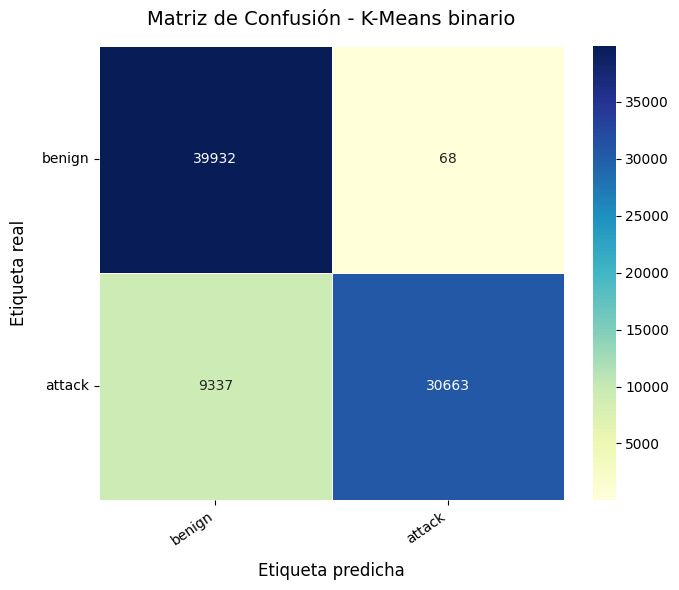

In [21]:
graficar_matriz_confusion(
    matriz_confusion_binaria_df,
    "Matriz de Confusión - K-Means binario",
    "img/matriz_confusion_kmeans_binario_legible.png",
    figsize=(7, 6)
)

In [22]:
metricas_kmeans_bin = calcular_metricas(
    df_binario["Etiqueta_binaria"],
    df_binario["Etiqueta_binaria_predicha"]
)

ari_bin = adjusted_rand_score(
    df_binario["Etiqueta_binaria"],
    df_binario["Cluster_binario"]
)

nmi_bin = normalized_mutual_info_score(
    df_binario["Etiqueta_binaria"],
    df_binario["Cluster_binario"]
)

silhouette_bin = silhouette_score(
    X_bin_scaled,
    df_binario["Cluster_binario"]
)

print("Métricas K-Means binario:")
for metrica, valor in metricas_kmeans_bin.items():
    print(f"{metrica}: {valor}")

print("Adjusted Rand Index:", ari_bin)
print("Normalized Mutual Information:", nmi_bin)
print("Silhouette Score:", silhouette_bin)

print("\nReporte de clasificación:")
print(classification_report(
    df_binario["Etiqueta_binaria"],
    df_binario["Etiqueta_binaria_predicha"],
    zero_division=0
))

Métricas K-Means binario:
Exactitud: 0.8824375
Precisión: 0.9041383025098491
Sensibilidad: 0.8824375
F1-score: 0.880837853171855
Adjusted Rand Index: 0.5850288569554518
Normalized Mutual Information: 0.5710601289404774
Silhouette Score: 0.5535990358351889

Reporte de clasificación:
              precision    recall  f1-score   support

      attack       1.00      0.77      0.87     40000
      benign       0.81      1.00      0.89     40000

    accuracy                           0.88     80000
   macro avg       0.90      0.88      0.88     80000
weighted avg       0.90      0.88      0.88     80000



In [23]:
centroides_binarios = pd.DataFrame(
    scaler_bin.inverse_transform(kmeans_bin.cluster_centers_),
    columns=columnas
)

centroides_binarios["Cluster"] = centroides_binarios.index
centroides_binarios["Etiqueta_asignada"] = centroides_binarios["Cluster"].map(mapeo_binario)

centroides_binarios

,H_L0.1_weight,H_L0.1_mean,H_L0.1_variance,HH_jit_L0.01_mean,HpHp_L0.1_radius,Cluster,Etiqueta_asignada
0,1267.598792,103.670182,8595.788602,1.432119e+09,3.513482e-09,0,attack
1,439.895009,122.747144,15609.784065,3.498486e+07,1.420169e+04,1,benign


In [24]:
X_nb = df[columnas]
y_nb = df["Etiqueta"]

X_train, X_test, y_train, y_test = train_test_split(
    X_nb,
    y_nb,
    test_size=0.30,
    random_state=42,
    stratify=y_nb
)

scaler_nb = MinMaxScaler()

X_train_scaled = scaler_nb.fit_transform(X_train)
X_test_scaled = scaler_nb.transform(X_test)

modelo_nb = GaussianNB()
modelo_nb.fit(X_train_scaled, y_train)

y_pred_nb = modelo_nb.predict(X_test_scaled)

In [25]:
metricas_nb = calcular_metricas(y_test, y_pred_nb)

print("Métricas Gaussian Naive Bayes:")
for metrica, valor in metricas_nb.items():
    print(f"{metrica}: {valor}")

print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_pred_nb,
    zero_division=0
))

Métricas Gaussian Naive Bayes:
Exactitud: 0.99825
Precisión: 0.9982621418892963
Sensibilidad: 0.99825
F1-score: 0.9982524896650612

Reporte de clasificación:
              precision    recall  f1-score   support

      benign       1.00      1.00      1.00     12000
 gafgyt.scan       0.99      1.00      0.99      3000
  gafgyt.udp       1.00      1.00      1.00      3000
  mirai.scan       1.00      1.00      1.00      3000
   mirai.udp       1.00      1.00      1.00      3000

    accuracy                           1.00     24000
   macro avg       1.00      1.00      1.00     24000
weighted avg       1.00      1.00      1.00     24000



In [26]:
matriz_confusion_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=etiquetas
)

matriz_confusion_nb_df = pd.DataFrame(
    matriz_confusion_nb,
    index=etiquetas,
    columns=etiquetas
)

matriz_confusion_nb_df

,benign,gafgyt.scan,gafgyt.udp,mirai.scan,mirai.udp
benign,11971,27,2,0,0
gafgyt.scan,1,2999,0,0,0
gafgyt.udp,4,2,2994,0,0
mirai.scan,0,2,0,2998,0
mirai.udp,2,0,2,0,2996


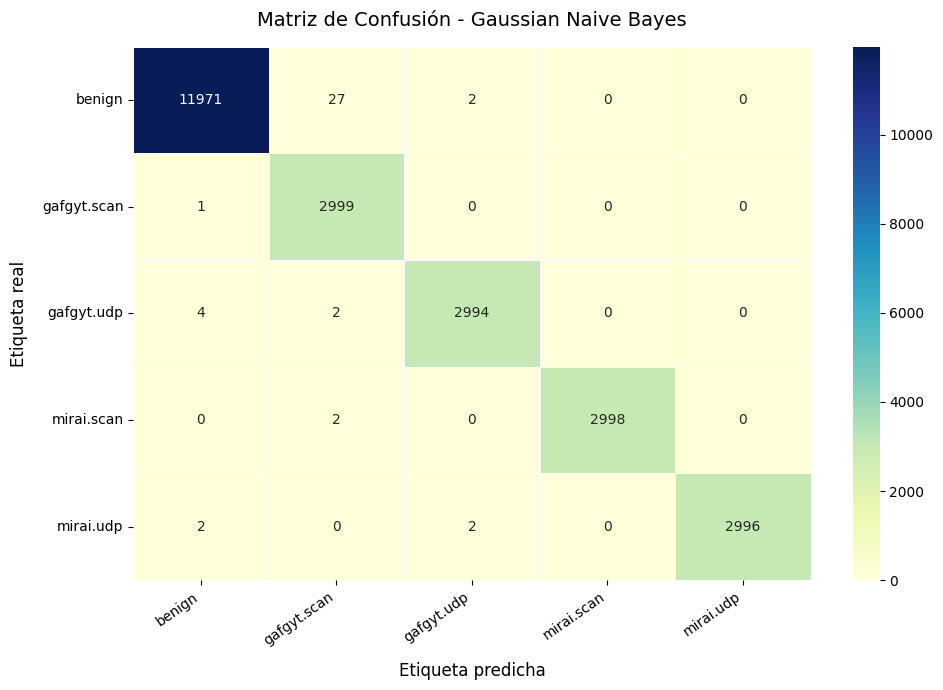

In [27]:
graficar_matriz_confusion(
    matriz_confusion_nb_df,
    "Matriz de Confusión - Gaussian Naive Bayes",
    "img/matriz_confusion_naive_bayes_legible.png",
    figsize=(10, 7)
)

In [28]:
X_if = df[columnas]
y_if = df["Etiqueta"]

X_train_if, X_test_if, y_train_if, y_test_if = train_test_split(
    X_if,
    y_if,
    test_size=0.30,
    random_state=42,
    stratify=y_if
)

print("Entrenamiento:", X_train_if.shape)
print("Prueba:", X_test_if.shape)
print("\nDistribución de prueba:")
print(y_test_if.value_counts())

Entrenamiento: (56000, 5)
Prueba: (24000, 5)

Distribución de prueba:
Etiqueta
benign         12000
mirai.udp       3000
gafgyt.udp      3000
mirai.scan      3000
gafgyt.scan     3000
Name: count, dtype: int64


In [29]:
scaler_if = MinMaxScaler()

X_train_if_scaled = scaler_if.fit_transform(X_train_if)
X_test_if_scaled = scaler_if.transform(X_test_if)

X_train_if_scaled = pd.DataFrame(X_train_if_scaled, columns=columnas)
X_test_if_scaled = pd.DataFrame(X_test_if_scaled, columns=columnas)

y_train_if = y_train_if.reset_index(drop=True)
y_test_if = y_test_if.reset_index(drop=True)

In [30]:
modelos_if = {}

for etiqueta in sorted(y_train_if.unique()):
    X_clase = X_train_if_scaled[y_train_if == etiqueta]

    modelo = IsolationForest(
        n_estimators=100,
        contamination=0.05,
        random_state=42
    )

    modelo.fit(X_clase)

    modelos_if[etiqueta] = modelo

print("Modelos entrenados:")
print(modelos_if.keys())

Modelos entrenados:
dict_keys(['benign', 'gafgyt.scan', 'gafgyt.udp', 'mirai.scan', 'mirai.udp'])


In [31]:
puntajes_if = pd.DataFrame(index=range(len(X_test_if_scaled)))

for etiqueta, modelo in modelos_if.items():
    puntajes_if[etiqueta] = modelo.score_samples(X_test_if_scaled)

# La clase predicha es la que obtiene mayor puntaje de normalidad
y_pred_if = puntajes_if.idxmax(axis=1)

y_pred_if.head()

,0
0,mirai.udp
1,benign
2,gafgyt.udp
3,benign
4,gafgyt.udp


In [32]:
metricas_if = calcular_metricas(y_test_if, y_pred_if)

print("Métricas Isolation Forest multiclase adaptado:")
for metrica, valor in metricas_if.items():
    print(f"{metrica}: {valor}")

print("\nReporte de clasificación:")
print(classification_report(
    y_test_if,
    y_pred_if,
    zero_division=0
))

Métricas Isolation Forest multiclase adaptado:
Exactitud: 0.9417916666666667
Precisión: 0.9602192426185672
Sensibilidad: 0.9417916666666667
F1-score: 0.9459211374204929

Reporte de clasificación:
              precision    recall  f1-score   support

      benign       1.00      0.96      0.98     12000
 gafgyt.scan       1.00      0.95      0.98      3000
  gafgyt.udp       0.68      1.00      0.81      3000
  mirai.scan       1.00      0.86      0.93      3000
   mirai.udp       1.00      0.89      0.94      3000

    accuracy                           0.94     24000
   macro avg       0.94      0.93      0.93     24000
weighted avg       0.96      0.94      0.95     24000



In [33]:
matriz_confusion_if = confusion_matrix(
    y_test_if,
    y_pred_if,
    labels=etiquetas
)

matriz_confusion_if_df = pd.DataFrame(
    matriz_confusion_if,
    index=etiquetas,
    columns=etiquetas
)

matriz_confusion_if_df

,benign,gafgyt.scan,gafgyt.udp,mirai.scan,mirai.udp
benign,11502,0,498,0,0
gafgyt.scan,0,2857,143,0,0
gafgyt.udp,2,0,2998,0,0
mirai.scan,0,0,409,2591,0
mirai.udp,0,0,345,0,2655


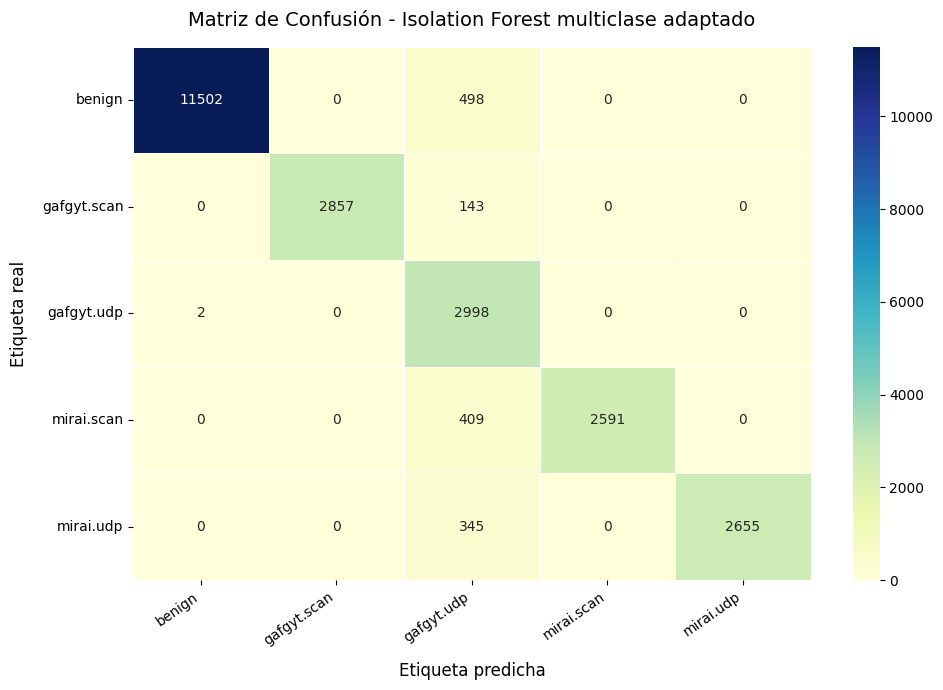

In [34]:
graficar_matriz_confusion(
    matriz_confusion_if_df,
    "Matriz de Confusión - Isolation Forest multiclase adaptado",
    "img/matriz_confusion_isolation_forest_multiclase.png",
    figsize=(10, 7)
)

In [35]:
# ============================================================
# ROC/AUC para detección binaria: benign vs attack
# ============================================================

# ---------- K-Means binario ----------
y_true_kmeans_bin = df_binario["Etiqueta_binaria"].map({
    "benign": 0,
    "attack": 1
})

cluster_benign = [c for c, e in mapeo_binario.items() if e == "benign"][0]
cluster_attack = [c for c, e in mapeo_binario.items() if e == "attack"][0]

distancias = kmeans_bin.transform(X_bin_scaled)

dist_benign = distancias[:, cluster_benign]
dist_attack = distancias[:, cluster_attack]

# Mientras más alto el score, más cercano a attack que a benign
score_kmeans = dist_benign - dist_attack

fpr_kmeans, tpr_kmeans, _ = roc_curve(y_true_kmeans_bin, score_kmeans)
auc_kmeans = roc_auc_score(y_true_kmeans_bin, score_kmeans)

print("AUC K-Means binario:", auc_kmeans)


# ---------- Gaussian Naive Bayes ----------
y_true_nb_bin = y_test.apply(lambda x: 0 if x == "benign" else 1)

probas_nb = modelo_nb.predict_proba(X_test_scaled)

indice_benign = list(modelo_nb.classes_).index("benign")

# Probabilidad de ataque = 1 - probabilidad de benign
score_nb = 1 - probas_nb[:, indice_benign]

fpr_nb, tpr_nb, _ = roc_curve(y_true_nb_bin, score_nb)
auc_nb = roc_auc_score(y_true_nb_bin, score_nb)

print("AUC Gaussian Naive Bayes:", auc_nb)


# ---------- Isolation Forest ----------
y_true_if_bin = y_test_if.apply(lambda x: 0 if x == "benign" else 1)

puntajes_if_roc = pd.DataFrame(index=range(len(X_test_if_scaled)))

for etiqueta, modelo in modelos_if.items():
    puntajes_if_roc[etiqueta] = modelo.score_samples(X_test_if_scaled)

score_benign_if = puntajes_if_roc["benign"]

columnas_ataque_if = [col for col in puntajes_if_roc.columns if col != "benign"]
score_attack_if = puntajes_if_roc[columnas_ataque_if].max(axis=1)

# Mientras más alto el score, más parecido a ataque que a benign
score_if = score_attack_if - score_benign_if

fpr_if, tpr_if, _ = roc_curve(y_true_if_bin, score_if)
auc_if = roc_auc_score(y_true_if_bin, score_if)

print("AUC Isolation Forest adaptado:", auc_if)

AUC K-Means binario: 0.9975351925
AUC Gaussian Naive Bayes: 0.9989069340277777
AUC Isolation Forest adaptado: 0.9995276527777777


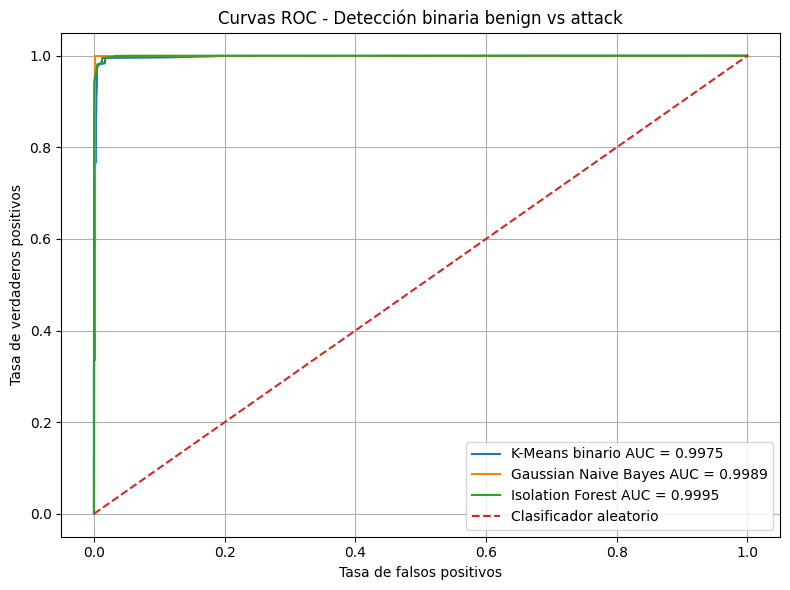

In [36]:
plt.figure(figsize=(8, 6))

plt.plot(fpr_kmeans, tpr_kmeans, label=f"K-Means binario AUC = {auc_kmeans:.4f}")
plt.plot(fpr_nb, tpr_nb, label=f"Gaussian Naive Bayes AUC = {auc_nb:.4f}")
plt.plot(fpr_if, tpr_if, label=f"Isolation Forest AUC = {auc_if:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")

plt.title("Curvas ROC - Detección binaria benign vs attack")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("img/curvas_roc_modelos.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
def auditar_kmeans_binario(weight, mean, variance, jit_mean, radius):
    nuevo = pd.DataFrame({
        "H_L0.1_weight": [weight],
        "H_L0.1_mean": [mean],
        "H_L0.1_variance": [variance],
        "HH_jit_L0.01_mean": [jit_mean],
        "HpHp_L0.1_radius": [radius]
    })

    nuevo_scaled = scaler_bin.transform(nuevo)

    cluster = kmeans_bin.predict(nuevo_scaled)[0]
    etiqueta = mapeo_binario[cluster]

    print("Auditoría con K-Means binario")
    print("-----------------------------")
    print("Cluster asignado:", cluster)
    print("Resultado estimado:", etiqueta)

    if etiqueta == "attack":
        print("Interpretación: posible tráfico anómalo o ataque.")
    else:
        print("Interpretación: posible tráfico benigno.")

In [38]:
fila = df.iloc[2]

auditar_kmeans_binario(
    fila["H_L0.1_weight"],
    fila["H_L0.1_mean"],
    fila["H_L0.1_variance"],
    fila["HH_jit_L0.01_mean"],
    fila["HpHp_L0.1_radius"]
)

Auditoría con K-Means binario
-----------------------------
Cluster asignado: 1
Resultado estimado: benign
Interpretación: posible tráfico benigno.


In [39]:
def auditar_naive_bayes(weight, mean, variance, jit_mean, radius):
    nuevo = pd.DataFrame({
        "H_L0.1_weight": [weight],
        "H_L0.1_mean": [mean],
        "H_L0.1_variance": [variance],
        "HH_jit_L0.01_mean": [jit_mean],
        "HpHp_L0.1_radius": [radius]
    })

    nuevo_scaled = scaler_nb.transform(nuevo)

    prediccion = modelo_nb.predict(nuevo_scaled)[0]
    probabilidades = modelo_nb.predict_proba(nuevo_scaled)[0]

    print("Auditoría con Gaussian Naive Bayes")
    print("----------------------------------")
    print("Etiqueta predicha:", prediccion)

    print("\nProbabilidades por clase:")
    for clase, prob in zip(modelo_nb.classes_, probabilidades):
        print(f"{clase}: {prob:.4f}")

In [40]:
fila = df.iloc[2]

auditar_naive_bayes(
    fila["H_L0.1_weight"],
    fila["H_L0.1_mean"],
    fila["H_L0.1_variance"],
    fila["HH_jit_L0.01_mean"],
    fila["HpHp_L0.1_radius"]
)

Auditoría con Gaussian Naive Bayes
----------------------------------
Etiqueta predicha: benign

Probabilidades por clase:
benign: 1.0000
gafgyt.scan: 0.0000
gafgyt.udp: 0.0000
mirai.scan: 0.0000
mirai.udp: 0.0000


In [41]:
resumen_modelos = pd.DataFrame([
    {
        "Modelo": "K-Means multiclase",
        "Exactitud": metricas_kmeans_multi["Exactitud"],
        "Precisión": metricas_kmeans_multi["Precisión"],
        "Sensibilidad / Recall": metricas_kmeans_multi["Sensibilidad"],
        "F1-score": metricas_kmeans_multi["F1-score"],
        "AUC binario": "N/A"
    },
    {
        "Modelo": "K-Means binario",
        "Exactitud": metricas_kmeans_bin["Exactitud"],
        "Precisión": metricas_kmeans_bin["Precisión"],
        "Sensibilidad / Recall": metricas_kmeans_bin["Sensibilidad"],
        "F1-score": metricas_kmeans_bin["F1-score"],
        "AUC binario": auc_kmeans
    },
    {
        "Modelo": "Isolation Forest multiclase adaptado",
        "Exactitud": metricas_if["Exactitud"],
        "Precisión": metricas_if["Precisión"],
        "Sensibilidad / Recall": metricas_if["Sensibilidad"],
        "F1-score": metricas_if["F1-score"],
        "AUC binario": auc_if
    },
    {
        "Modelo": "Gaussian Naive Bayes",
        "Exactitud": metricas_nb["Exactitud"],
        "Precisión": metricas_nb["Precisión"],
        "Sensibilidad / Recall": metricas_nb["Sensibilidad"],
        "F1-score": metricas_nb["F1-score"],
        "AUC binario": auc_nb
    }
])

resumen_modelos

,Modelo,Exactitud,Precisión,Sensibilidad / Recall,F1-score,AUC binario
0,K-Means multiclase,0.582725,0.620115,0.582725,0.574357,N/A
1,K-Means binario,0.882437,0.904138,0.882437,0.880838,0.997535
2,Isolation Forest multiclase adaptado,0.941792,0.960219,0.941792,0.945921,0.999528
3,Gaussian Naive Bayes,0.998250,0.998262,0.998250,0.998252,0.998907


In [42]:
resumen_modelos.to_csv("resumen_modelos.csv", index=False)

matriz_confusion_multi_df.to_csv("matriz_confusion_kmeans_multiclase.csv")
matriz_confusion_binaria_df.to_csv("matriz_confusion_kmeans_binario.csv")
matriz_confusion_nb_df.to_csv("matriz_confusion_naive_bayes.csv")
matriz_confusion_if_df.to_csv("matriz_confusion_isolation_forest.csv")

print("Archivos generados correctamente.")

Archivos generados correctamente.
